In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["AL", "AO", "CU", "NI", "PB","SN","ZN"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")

    init_money_lst.append(int(margin / 0.4))


品种: AL (铝)
  首个交易日: 2021-02-08
  95分位数价格: 24390.00
  合约乘数: 5
  保证金率: 9.00%
  10手保证金: 109,755.00
  40%保证金所需本金: 274,388 
  分均持仓量: 252,037
  分均成交量: 655
  分均成交额: 72,981,359

品种: AO (氧化铝)
  首个交易日: 2023-06-19
  95分位数价格: 3241.00
  合约乘数: 20
  保证金率: 11.00%
  10手保证金: 71,302.00
  40%保证金所需本金: 178,255 
  分均持仓量: 301,444
  分均成交量: 1,326
  分均成交额: 78,048,771

品种: CU (铜)
  首个交易日: 2021-02-08
  95分位数价格: 102760.00
  合约乘数: 5
  保证金率: 9.00%
  10手保证金: 462,420.00
  40%保证金所需本金: 1,156,050 
  分均持仓量: 194,172
  分均成交量: 395
  分均成交额: 176,930,078

品种: NI (镍)
  首个交易日: 2021-02-08
  95分位数价格: 142230.00
  合约乘数: 1
  保证金率: 12.00%
  10手保证金: 170,676.00
  40%保证金所需本金: 426,690 
  分均持仓量: 104,010
  分均成交量: 674
  分均成交额: 88,592,797

品种: PB (铅)
  首个交易日: 2021-02-08
  95分位数价格: 17585.00
  合约乘数: 5
  保证金率: 9.00%
  10手保证金: 79,132.50
  40%保证金所需本金: 197,831 
  分均持仓量: 52,689
  分均成交量: 114
  分均成交额: 9,729,591

品种: SN (锡)
  首个交易日: 2021-02-08
  95分位数价格: 413690.00
  合约乘数: 1
  保证金率: 12.00%
  10手保证金: 496,428.00
  40%保证金所需本金: 1,241,070 
  分均持仓量: 34,436
  分

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'AL': 274387,
 'AO': 178255,
 'CU': 1156050,
 'NI': 426690,
 'PB': 197831,
 'SN': 1241069,
 'ZN': 277931}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'AL': 18, 'AO': 28, 'CU': 4, 'NI': 11, 'PB': 25, 'SN': 4, 'ZN': 17}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*465)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = r'/home/strategy_res/multi_train/models/test_model'

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    # bt.load_factor(symbol, end_date=bt.window_end)

    factor_single = pd.read_feather(r'/home/strategy_res/multi_train/merged_df/AL_AO_CU_NI_PB_SN_ZN.feather')
    factor_single = factor_single[factor_single['symbol'] == symbol].reset_index(drop=True)
    factor_single['hour'] = factor_single.datetime.dt.hour
    factor_single = factor_single[factor_single.datetime >= train_end_date]
    # factor_single = factor_single[factor_single.datetime.astype('datetime64[ns]').between(start_date, end_date)]
    
    factor_single = factor_single.sort_values('datetime').drop_duplicates('datetime', keep='last')
    factor_single = factor_single[~((factor_single['datetime'].dt.hour == 10) & (factor_single['datetime'].dt.minute == 30))]
    factor_single['datetime'] = pd.to_datetime(factor_single.datetime)
    bt.factor_single = factor_single.round(8) 

    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = []
for symbol in symbol_lst:
    print(f"\nProcessing {symbol}...")
    merged_data = run_res(symbol, bt_params)
    merged_data_lst.append(merged_data)


Processing AL...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']


  0%|          | 0/111097 [00:00<?, ?it/s]


Processing AO...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']
使用的交易价格 tick6t60avg


计算持仓表:   0%|          | 0/111105 [00:00<?, ?it/s]


Processing CU...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']


...

  0%|          | 0/111178 [00:00<?, ?it/s]


Processing SN...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']


  0%|          | 0/111270 [00:00<?, ?it/s]


Processing ZN...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']


  0%|          | 0/111267 [00:00<?, ?it/s]

In [10]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        # df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-30]

In [11]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,AL,AO,CU,NI,PB,SN,ZN
date,,,,,,,
2025-01-02,4.945145e+06,4.911254e+06,4.621298e+06,4.600597e+06,4.942350e+06,4.946544e+06,4.742611e+06
2025-01-03,4.831474e+06,5.211035e+06,4.564453e+06,4.618501e+06,4.947892e+06,4.966817e+06,4.503145e+06
2025-01-06,4.865439e+06,4.962169e+06,4.481363e+06,4.707103e+06,5.055685e+06,4.887668e+06,4.493116e+06
2025-01-07,4.877224e+06,4.928267e+06,4.431780e+06,4.712142e+06,5.039056e+06,4.836582e+06,4.474975e+06
2025-01-08,4.903080e+06,5.173406e+06,4.442392e+06,4.643065e+06,5.030343e+06,4.825753e+06,4.434803e+06
...,...,...,...,...,...,...,...
2026-01-12,9.857080e+06,1.477245e+07,1.047025e+07,7.065728e+06,1.066061e+07,9.453091e+06,7.931972e+06
2026-01-13,9.622981e+06,1.539546e+07,1.027973e+07,7.346971e+06,1.060276e+07,9.588200e+06,7.815449e+06
2026-01-14,9.647063e+06,1.551583e+07,1.049719e+07,7.307335e+06,1.066586e+07,1.028641e+07,7.904234e+06


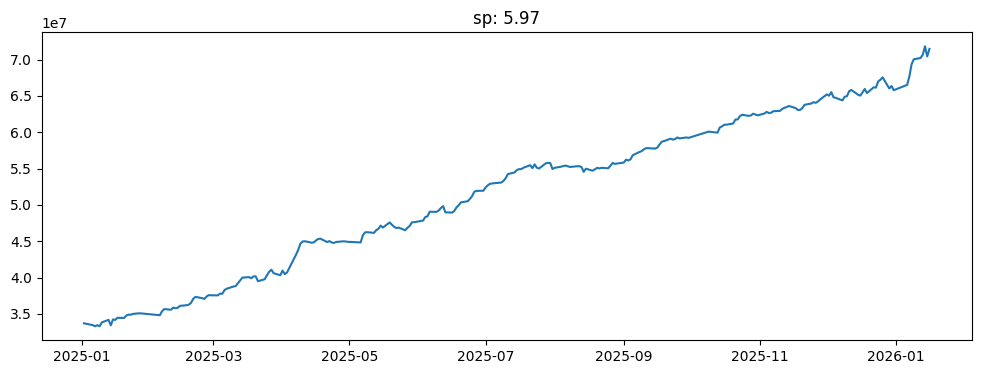

In [12]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

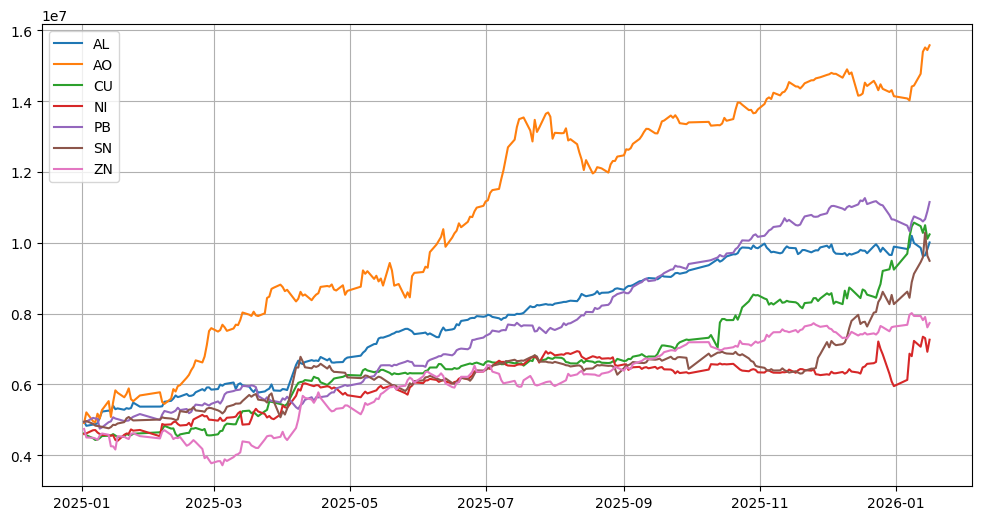

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [14]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,AL,AO,CU,NI,PB,SN,ZN
多头(+1) 数量,23253,22186,23149,22115,23041,22781,23135
空头(-1) 数量,19103,19504,20556,22305,18247,21429,18996
空仓(0) 数量,68743,69417,67183,66691,69892,67062,69138
多头占比,20.93%,19.97%,20.88%,19.90%,20.72%,20.47%,20.79%
空头占比,17.19%,17.55%,18.54%,20.07%,16.41%,19.26%,17.07%
空仓占比,61.88%,62.48%,60.59%,60.02%,62.86%,60.27%,62.14%
交易日数量,283,283,283,283,283,283,283
总收益(非年化%),86.10,247.80,129.80,76.44,134.20,152.35,13.56
总交易次数（开平算一次）,6317,6382,5824,4512,7038,4106,6346
日均交易次数（开平算一次）,22.32,22.55,20.58,15.95,24.87,14.51,22.43
